Number of rows: 9551
Number of columns: 21

Missing values in each column:
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

Missing values after handling: 0


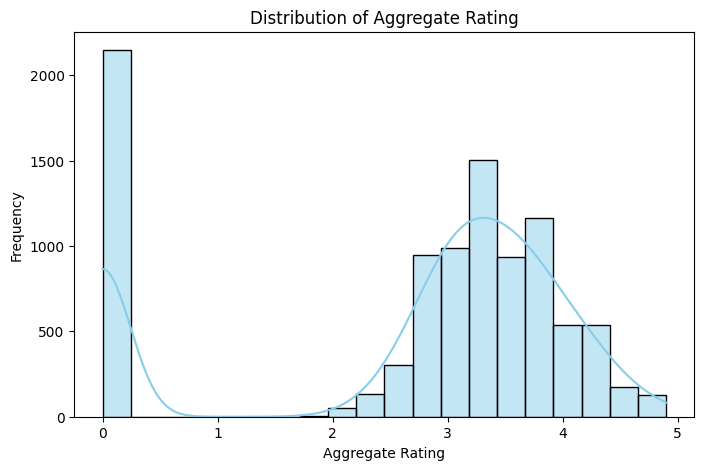


Number of restaurants with a 0.0 rating: 2148


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df = pd.read_csv('../data/Dataset.csv')

# 2. Explore rows and columns
print(f"Number of rows: {df.shape[0]}")

print(f"Number of columns: {df.shape[1]}")

# 3. Check for missing values
print("\nMissing values in each column:")
print(df.isnull().sum())

# 4. Handle missing values 
# Since there are only 9 missing values in 'Cuisines' out of 9551 rows, 
# we can safely fill them with 'Unknown' or drop them. Let's fill them.
df['Cuisines'] = df['Cuisines'].fillna('Unknown')
print(f"\nMissing values after handling: {df['Cuisines'].isnull().sum()}")

# 5. Analyze the distribution of the target variable ("Aggregate rating")
plt.figure(figsize=(8, 5))
sns.histplot(df['Aggregate rating'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Aggregate Rating')
plt.xlabel('Aggregate Rating')
plt.ylabel('Frequency')
plt.show()

# Check for class imbalances (count of zero ratings vs others)
zero_ratings = (df['Aggregate rating'] == 0.0).sum()
print(f"\nNumber of restaurants with a 0.0 rating: {zero_ratings}")

--- Basic Statistical Measures (Numerical Columns) ---


,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000



--- Top 10 Cities with the Highest Number of Restaurants ---
City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Lucknow           21
Ahmedabad         21
Amritsar          21
Guwahati          21
Name: count, dtype: int64

--- Top 10 Cuisines with the Highest Number of Restaurants ---
Cuisines
North Indian                      936
North Indian, Chinese             511
Fast Food                         354
Chinese                           354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64


C:\Users\garvi\AppData\Local\Temp\ipykernel_22740\396124120.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_cities.index, x=top_cities.values, palette='magma')


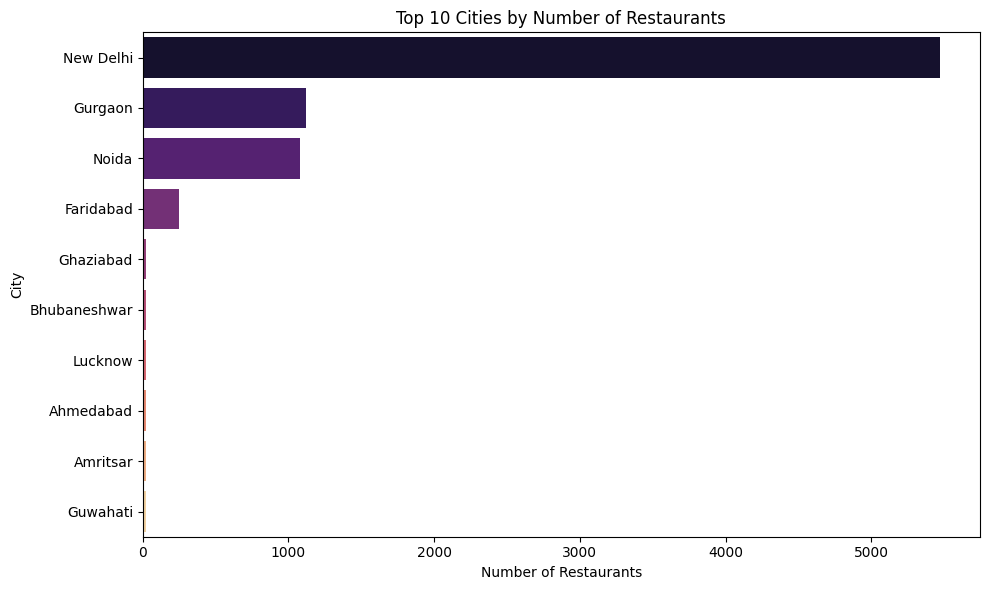

In [3]:
# --- Task 2: Descriptive Analysis ---

# 1. Calculate basic statistical measures for numerical columns
print("--- Basic Statistical Measures (Numerical Columns) ---")
display(df.describe()) # Using display() in Jupyter makes the table look much cleaner

# 2 & 3. Explore categorical variables and identify top cities and cuisines
print("\n--- Top 10 Cities with the Highest Number of Restaurants ---")
top_cities = df['City'].value_counts().head(10)
print(top_cities)

print("\n--- Top 10 Cuisines with the Highest Number of Restaurants ---")
# This counts the exact string combinations in the Cuisines column
top_cuisines = df['Cuisines'].value_counts().head(10)
print(top_cuisines)

# Let's plot the top cities to make the analysis visual
plt.figure(figsize=(10, 6))
sns.barplot(y=top_cities.index, x=top_cities.values, palette='magma')
plt.title('Top 10 Cities by Number of Restaurants')
plt.xlabel('Number of Restaurants')
plt.ylabel('City')
plt.tight_layout()
plt.show()

--- 1. Generating Interactive Map ---
Map successfully generated! (Run 'restaurant_map' in a new cell to view it)

--- 2. Distribution Across Top Cities ---


C:\Users\garvi\AppData\Local\Temp\ipykernel_22740\1606096265.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_15_cities.values, y=top_15_cities.index, palette='viridis')


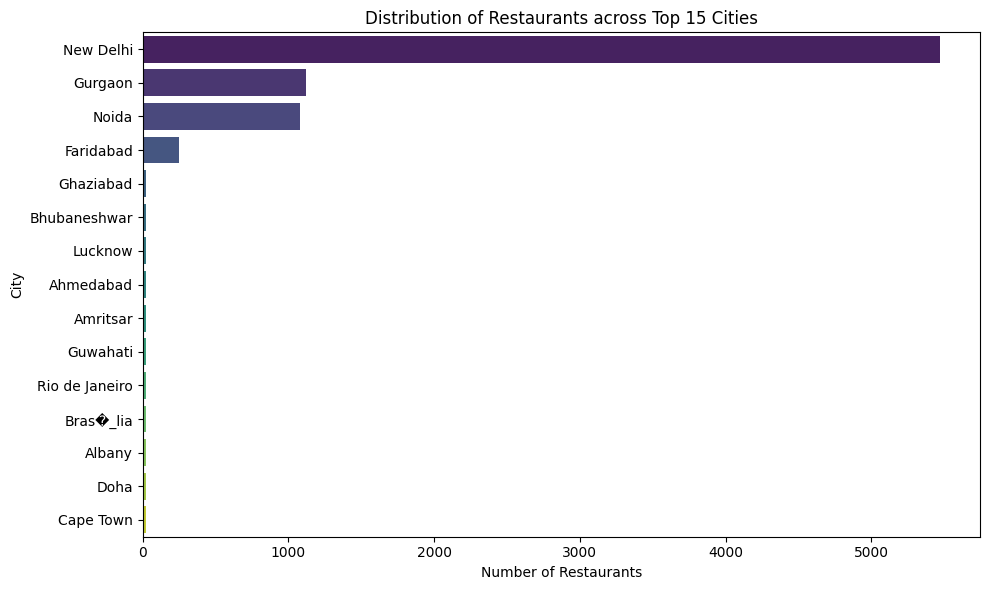


--- 3. Correlation: Location vs. Rating ---
Correlation Matrix values:
                  Longitude  Latitude  Aggregate rating
Longitude          1.000000 -0.200034         -0.206468
Latitude          -0.200034  1.000000         -0.124381
Aggregate rating  -0.206468 -0.124381          1.000000


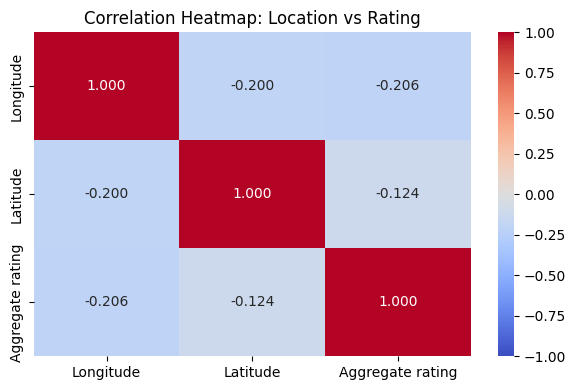

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import MarkerCluster

# Assuming 'df' is already loaded from the previous tasks.
# Filter out any rows with missing or zero coordinates to ensure map accuracy
valid_locations = df[(df['Longitude'] != 0) & (df['Latitude'] != 0)]

# --- Condition 1: Visualize the locations of restaurants on a map ---
print("--- 1. Generating Interactive Map ---")

# Create a base map centered around the average coordinates of the dataset
center_lat = valid_locations['Latitude'].mean()
center_lon = valid_locations['Longitude'].mean()
restaurant_map = folium.Map(location=[center_lat, center_lon], zoom_start=2)

# Use MarkerCluster to handle plotting thousands of points without crashing the browser
marker_cluster = MarkerCluster().add_to(restaurant_map)

# We take a random sample of 1000 restaurants for the map to keep it fast and responsive.
# If your machine is powerful, you can remove '.sample(1000)' to map all 9,500+ locations.
for idx, row in valid_locations.sample(1000, random_state=42).iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=6,
        # The popup shows the name and rating when you click a dot on the map!
        popup=f"<b>{row['Restaurant Name']}</b><br>Rating: {row['Aggregate rating']}",
        color='green' if row['Aggregate rating'] >= 4.0 else 'orange',
        fill=True,
        fill_color='green' if row['Aggregate rating'] >= 4.0 else 'orange'
    ).add_to(marker_cluster)

# Note: To view the interactive map in Jupyter Notebook, simply type 'restaurant_map' 
# in the next empty cell and run it!
print("Map successfully generated! (Run 'restaurant_map' in a new cell to view it)")
# Save the map to an HTML file
restaurant_map.save("restaurant_locations_map.html")


# --- Condition 2: Analyze the distribution across different cities/countries ---
print("\n--- 2. Distribution Across Top Cities ---")
plt.figure(figsize=(10, 6))

# We'll plot the top 15 cities to get a clear distribution view
top_15_cities = df['City'].value_counts().head(15)
sns.barplot(x=top_15_cities.values, y=top_15_cities.index, palette='viridis')

plt.title('Distribution of Restaurants across Top 15 Cities')
plt.xlabel('Number of Restaurants')
plt.ylabel('City')
plt.tight_layout()
plt.show()


# --- Condition 3: Determine correlation between location and rating ---
print("\n--- 3. Correlation: Location vs. Rating ---")
# Extract only the necessary columns for the correlation check
location_rating_df = valid_locations[['Longitude', 'Latitude', 'Aggregate rating']]

# Calculate the Pearson correlation matrix
correlation_matrix = location_rating_df.corr()
print("Correlation Matrix values:")
print(correlation_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".3f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap: Location vs Rating')
plt.tight_layout()
plt.show()

In [5]:
restaurant_map